# 12 - Matrix Profile: Motifs and Discords

**Problem framing.** Given one long time series and no labels, we want two things: the *motifs* (patterns that repeat) and the *discords* (the most unusual subsequences - anomalies). The matrix profile answers both at once. For every length-`w` subsequence it stores the z-normalised distance to its nearest neighbour elsewhere in the series: low values are motifs, high values are discords.

**Assumptions.** The series is largely repetitive, so normal subsequences have a close match; the window length `w` is on the scale of the pattern of interest; and z-normalisation (shape, not magnitude) is appropriate.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.timeseries import matrix_profile, top_discords, top_motifs

## A repetitive series with an injected anomaly

The background is a repeating sine wave (period = window), so most subsequences have many near-identical neighbours. We break the repetition with a flat segment - an anomaly that has *normal magnitude* but the wrong *shape*, which is exactly the kind a point-wise detector misses.

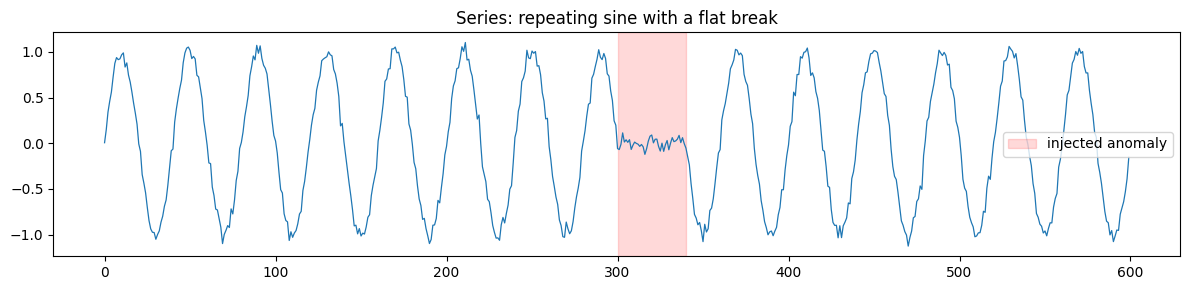

In [2]:
rng = np.random.default_rng(0)
window = 40
n = 600
t = np.arange(n)
series = np.sin(2 * np.pi * t / window) + rng.normal(scale=0.05, size=n)
anomaly = 300
series[anomaly : anomaly + window] = rng.normal(scale=0.05, size=window)  # flat break

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(series, lw=0.9)
ax.axvspan(anomaly, anomaly + window, color="red", alpha=0.15, label="injected anomaly")
ax.set_title("Series: repeating sine with a flat break")
ax.legend()
plt.tight_layout()
plt.show()

## The matrix profile

The profile is low across the repetitive region (every window has a neighbour) and spikes sharply over the anomaly, whose shape matches nothing else.

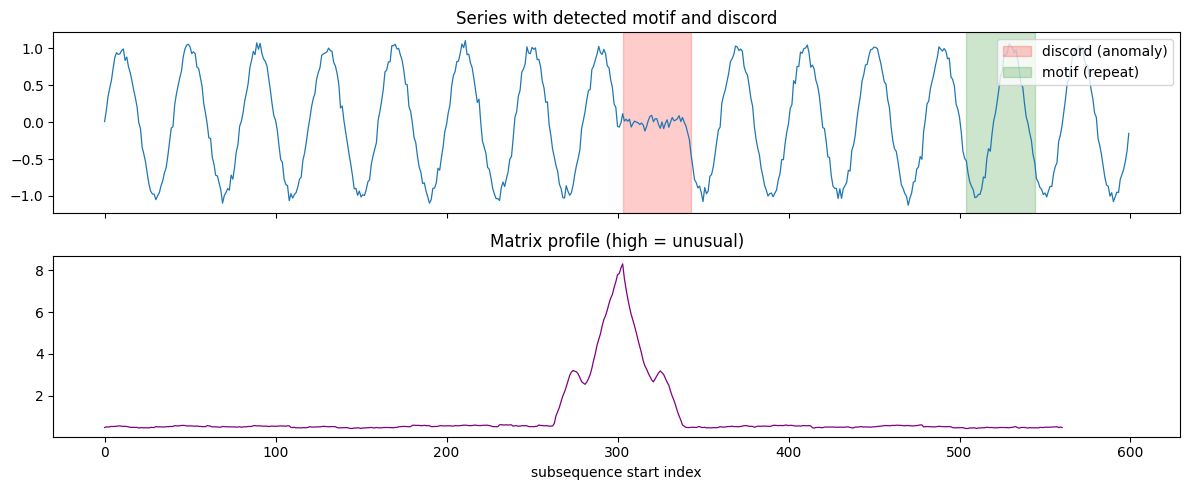

discord at 303 (injected at 300)
profile at discord: 8.31 vs median 0.53


In [3]:
profile, _ = matrix_profile(series, window)
discord = top_discords(profile, window, k=1)[0]
motif = top_motifs(profile, window, k=1)[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(series, lw=0.9)
ax1.axvspan(discord, discord + window, color="red", alpha=0.2, label="discord (anomaly)")
ax1.axvspan(motif, motif + window, color="green", alpha=0.2, label="motif (repeat)")
ax1.set_title("Series with detected motif and discord")
ax1.legend(loc="upper right")
ax2.plot(profile, color="purple", lw=0.9)
ax2.set_title("Matrix profile (high = unusual)")
ax2.set_xlabel("subsequence start index")
plt.tight_layout()
plt.show()

print(f"discord at {discord} (injected at {anomaly})")
print(f"profile at discord: {profile[discord]:.2f} vs median {np.median(profile):.2f}")

## Baseline: point-wise z-score

The standard quick anomaly check flags points whose value is far from the mean. But the flat break has perfectly normal *magnitude* - it is only anomalous in *shape* - so the z-score sees nothing, while the matrix profile flags it clearly.

In [4]:
z = np.abs((series - series.mean()) / series.std())
flagged_in_break = [i for i in np.where(z > 3)[0] if anomaly <= i < anomaly + window]

print(f"max |z-score| inside the anomaly: {z[anomaly : anomaly + window].max():.2f}")
print(f"points flagged by |z| > 3 inside the anomaly: {flagged_in_break}")
print(f"matrix profile rank of the anomaly: discord #1 at index {discord}")

max |z-score| inside the anomaly: 0.17
points flagged by |z| > 3 inside the anomaly: []
matrix profile rank of the anomaly: discord #1 at index 303


## Interpretation and limitations

The matrix profile finds the repeated motif and the shape anomaly in a single pass, with no labels and no threshold tuning, and catches a contextual anomaly that a magnitude-based z-score completely misses.

**Limitations.**

- The window length `w` is a real choice: it must match the scale of the pattern, and anomalies much shorter or longer than `w` can be missed.
- The brute-force computation here is O(n^2 * w); production use needs the fast MASS/STOMP algorithms that exploit the FFT.
- It assumes a repetitive signal; on non-repetitive data almost everything looks like a discord.
- Z-normalisation ignores amplitude, so a pattern that is anomalous only in scale will not stand out - z-normalise deliberately, not by reflex.